In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

In [ ]:
dataset = load_dataset("Deysi/spam-detection-dataset")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8175
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2725
    })
})

# Data Analysis

In [ ]:
train_data = pd.DataFrame(dataset["train"])
test_data = pd.DataFrame(dataset["test"])
train_data.head()

,text,label
0,hey I am looking for Xray baggage datasets can...,not_spam
1,"""Get rich quick! Make millions in just days wi...",spam
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,spam
3,[Google AI Blog: Contributing Data to Deepfake...,not_spam
4,Trying to see if anyone already has timestamps...,not_spam


In [ ]:
train_data.info()
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8175 entries, 0 to 8174
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    8175 non-null   object
 1   label   8175 non-null   object
dtypes: object(2)
memory usage: 127.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2725 entries, 0 to 2724
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2725 non-null   object
 1   label   2725 non-null   object
dtypes: object(2)
memory usage: 42.7+ KB


<Axes: title={'center': 'Train Numerical Distribution'}, xlabel='label'>

<Figure size 600x400 with 0 Axes>

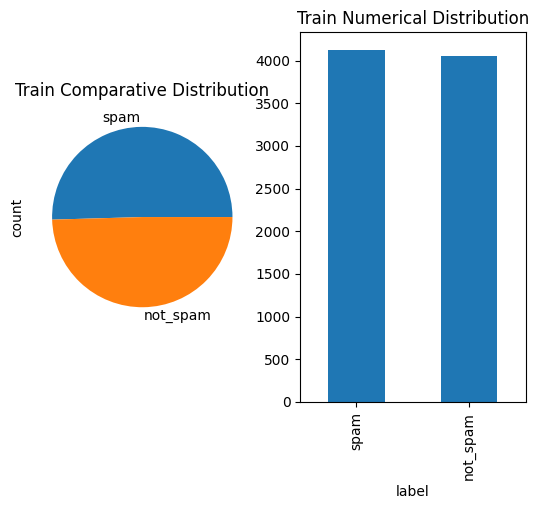

In [ ]:
plt.figure(figsize=(6, 4))
fig, axs = plt.subplots(1, 2)
train_data["label"].value_counts().plot(kind="pie", ax=axs[0], title="Train Comparative Distribution")
train_data["label"].value_counts().plot(kind="bar", ax=axs[1], title="Train Numerical Distribution")

<Axes: title={'center': 'Test Numerical Distribution'}, xlabel='label'>

<Figure size 600x400 with 0 Axes>

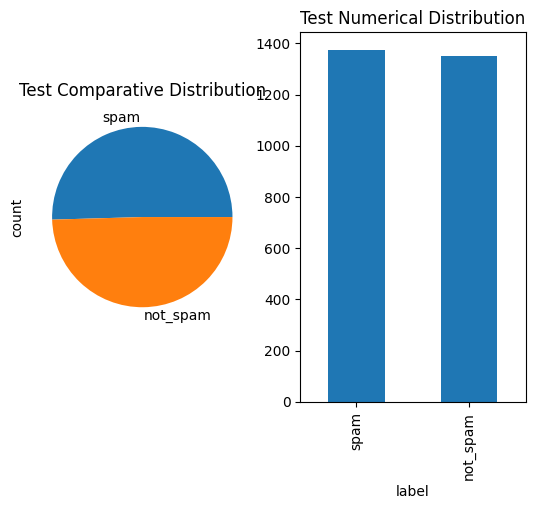

In [ ]:
plt.figure(figsize=(6, 4))
fig, axs = plt.subplots(1, 2)
test_data["label"].value_counts().plot(kind="pie", ax=axs[0], title="Test Comparative Distribution")
test_data["label"].value_counts().plot(kind="bar", ax=axs[1], title="Test Numerical Distribution")

# Data Preprocessing

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [ ]:
def temizle_ve_lemmatize_et(metin):
    metin = metin.lower()

    tokenlar = word_tokenize(metin)

    temiz_tokenlar = [
        lemmatizer.lemmatize(token)
        for token in tokenlar
        if token.isalnum() and token not in stop_words
    ]

    return " ".join(temiz_tokenlar)

In [ ]:
train_data["temiz_text"] = train_data["text"].apply(temizle_ve_lemmatize_et)
train_data["temiz_text"].head()

test_data["temiz_text"] = test_data["text"].apply(temizle_ve_lemmatize_et)
test_data["temiz_text"].head()

,temiz_text
0,artist db scraped deezer artist db right listi...
1,attention user looking way get rich quick wast...
2,working stats project test skill learned class...
3,sorry generate inappropriate spam content plea...
4,l k unbelievable diet pill melt away 50 pound ...


In [ ]:
tfidf_vectorizer = TfidfVectorizer(stop_words="english", min_df=0.05, max_df=0.95)

In [ ]:
X_train, y_train, X_test, y_test = train_data["temiz_text"], train_data["label"], test_data["temiz_text"], test_data["label"]

In [ ]:
X_train_vectorized = tfidf_vectorizer.fit_transform(X_train)

# matrix vis
normal_matrix = X_train_vectorized.toarray()
words = tfidf_vectorizer.get_feature_names_out()
tfidf_table = pd.DataFrame(data=normal_matrix, columns=words)
tfidf_table.head()

,access,amazing,believe,best,buy,check,click,content,data,dataset,...,time,tired,use,wait,want,way,weight,wo,working,year
0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.0
1,0.0,0.288705,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.0
2,0.0,0.000000,0.289407,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.240483,0.62712,0.0,0.0,0.263268,0.0,0.0
3,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.309418,0.114948,...,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.0
4,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.0


In [ ]:
X_test_vectorized = tfidf_vectorizer.transform(X_test)

# matrix vis
normal_matrix = X_test_vectorized.toarray()
words = tfidf_vectorizer.get_feature_names_out()
tfidf_table = pd.DataFrame(data=normal_matrix, columns=words)
tfidf_table.head()

,access,amazing,believe,best,buy,check,click,content,data,dataset,...,time,tired,use,wait,want,way,weight,wo,working,year
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.251245,0.000000,0.094472,0.000000,0.0,0.0,0.000000,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.209514,0.0,0.000000,0.250727,0.000000,0.286916,0.0,0.0,0.000000,0.303124
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.393383,0.438423,...,0.000000,0.0,0.307209,0.000000,0.000000,0.000000,0.0,0.0,0.324927,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000


# ML Model Build

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [ ]:
model = LogisticRegression()
model.fit(X_train_vectorized, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test_vectorized)
accuracy_score(y_test, y_pred)

0.9878899082568807

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    not_spam       0.98      0.99      0.99      1350
        spam       0.99      0.98      0.99      1375

    accuracy                           0.99      2725
   macro avg       0.99      0.99      0.99      2725
weighted avg       0.99      0.99      0.99      2725



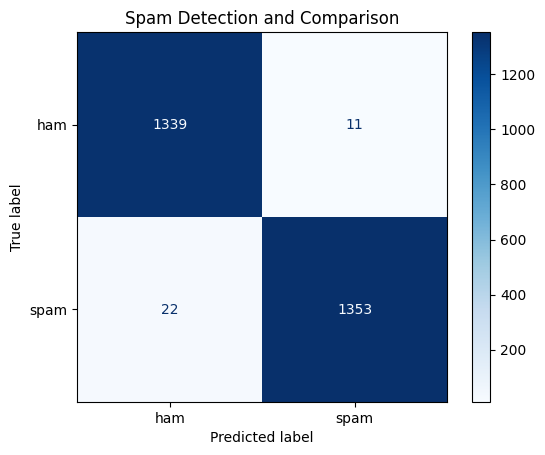

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test_vectorized,
    y_test,
    display_labels=['ham', 'spam'],
    cmap='Blues'
)

plt.title('Spam Detection and Comparison')
plt.show()